In [24]:
import quadriga_lib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import subprocess
import sys

print(quadriga_lib.components())

base_dir = '/sjc/quadriga-lib/tools/thin_sheet_test/'
fn_obj = 'model.obj'


quadriga-lib = 0.12.1
Armadillo    = 15.2.1
HDF5         = 2.1.0
Python       = 3.14.5
pybind11     = 3.0.0
NumPy        = 2.4.6



In [ ]:
# Model
material = 'itu_glass'
thickness = 0.005
n = 500

orig = np.stack([np.full(n, -5.0), np.full(n, 0.0), np.full(n, 1.0)], axis=1)
dest = np.stack([np.full(n, 5.0), np.linspace(0, 99, n), np.full(n, 1.0)], axis=1)

d = dest - orig
aod_az = np.degrees(np.arctan2(d[:, 1], d[:, 0]))
dist = np.linalg.norm(dest - orig, axis=1)

# Cube mesh
_, _, _, _, _, _, _, _, _, mtl_names, mtl_prop =  quadriga_lib.RTtools.obj_file_read() # Default table
mesh = quadriga_lib.RTtools.cube( scale=[thickness/2,100,100] )
mtl_ind = np.full(np.shape(mesh)[0], mtl_names.index(material)+1, dtype=int)     # 1-based index 

# Plane mesh
mtl_prop_plane = mtl_prop
mtl_prop_plane['thk'] = np.full(len(mtl_names), thickness)
plane = quadriga_lib.RTtools.plane( scale=[100,100], rotation=[0,-np.pi/2,0] )

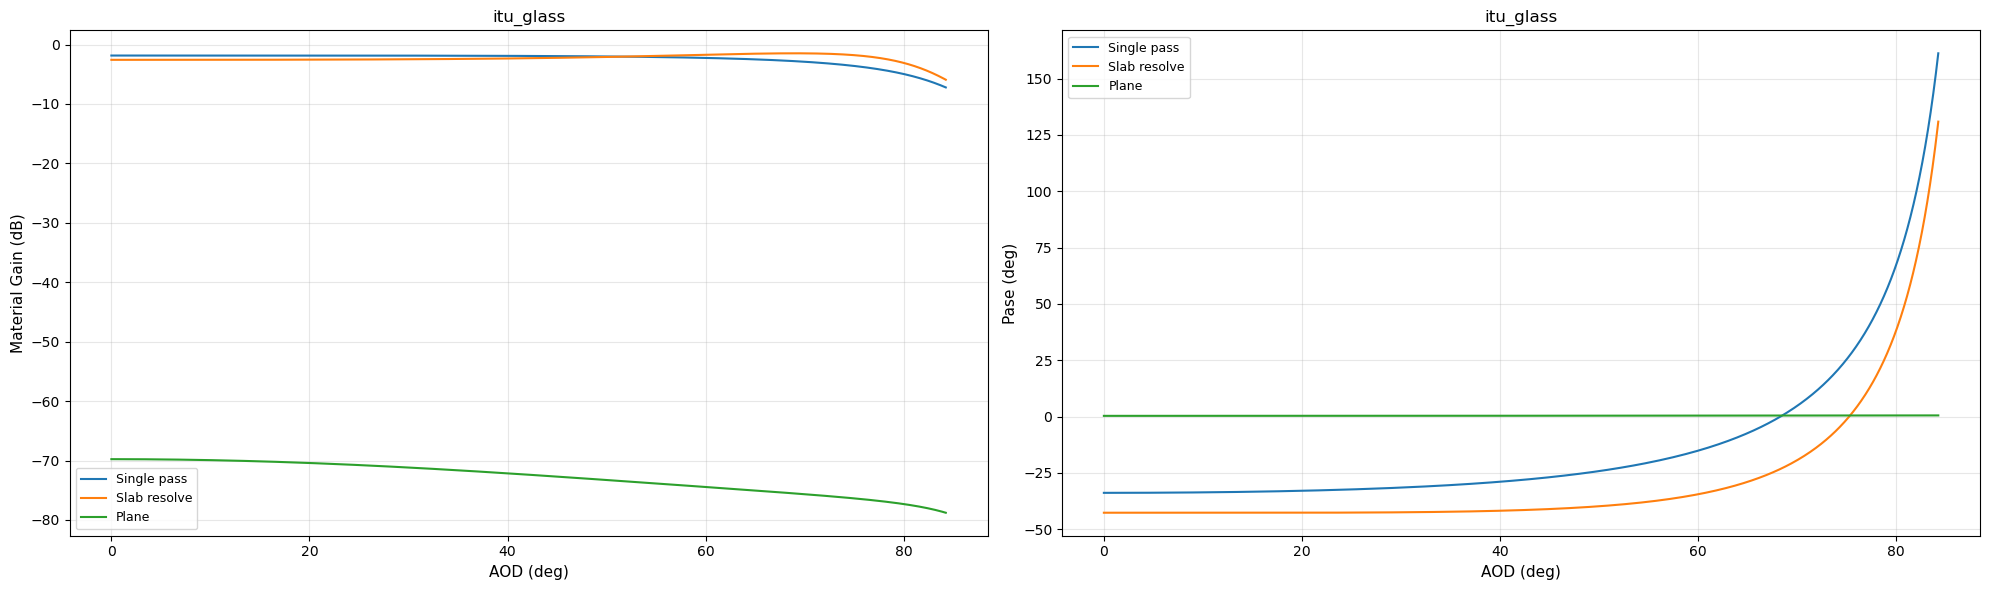

In [27]:
# Transmission
gain_1, xpr_1, _ = quadriga_lib.RTtools.calc_diffraction_gain( orig, dest, mesh, mtl_ind, mtl_prop, center_frequency=3.75e9, lod=1, thin_slab_threshold=1 )
gain_S, xpr_S, _ = quadriga_lib.RTtools.calc_diffraction_gain( orig, dest, mesh, mtl_ind, mtl_prop, center_frequency=3.75e9, lod=1, thin_slab_threshold=0 )
gain_P, xpr_P, _ = quadriga_lib.RTtools.calc_diffraction_gain( orig, dest, plane, mtl_ind[0:2], mtl_prop_plane, center_frequency=3.75e9, lod=1 )

phase_1 =  np.arctan2(xpr_1[1,:], xpr_1[0,:]) * 180/np.pi
phase_S =  np.arctan2(xpr_S[1,:], xpr_S[0,:]) * 180/np.pi
phase_P =  np.arctan2(xpr_P[1,:], xpr_P[0,:]) * 180/np.pi

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

ax = axes[0]
ax.plot(aod_az, 10.0 * np.log10(gain_1), label=f'Single pass', linewidth=1.5)
ax.plot(aod_az, 10.0 * np.log10(gain_S), label=f'Slab resolve', linewidth=1.5)
ax.plot(aod_az, 10.0 * np.log10(gain_P), label=f'Plane', linewidth=1.5)
ax.set_xlabel('AOD (deg)', fontsize=11)
ax.set_ylabel('Material Gain (dB)', fontsize=11)
ax.set_title(mtl_names[mtl_ind[0]-1])
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(aod_az, phase_1, label=f'Single pass', linewidth=1.5)
ax.plot(aod_az, phase_S, label=f'Slab resolve', linewidth=1.5)
ax.plot(aod_az, phase_P, label=f'Plane', linewidth=1.5)
ax.set_xlabel('AOD (deg)', fontsize=11)
ax.set_ylabel('Pase (deg)', fontsize=11)
ax.set_title(mtl_names[mtl_ind[0]-1])
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()